In [1]:
import pandas as pd
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei"]
plt.rcParams["axes.unicode_minus"] = False

In [2]:
path_long = r"C:\Users\Administrator\Desktop\long-customer-train.csv"

In [3]:
print("\n===== 开始处理长期数据 long-customer-train =====")
df_long = pd.read_csv(path_long)
origin_long_rows = df_long.shape[0]
print(f"长期原始总行数：{origin_long_rows}")


===== 开始处理长期数据 long-customer-train =====
长期原始总行数：9300


In [4]:
# 步骤1：清理Age字段字符：剔除空格、“岁”，只保留数字
def clean_age(x):
    if pd.isna(x):
        return x
    s = str(x).strip()
    # 去掉中文“岁”、空格等字符，只提取数字
    num_list = re.findall(r"\d+", s)
    if len(num_list)>=1:
        return int(num_list[0])
    else:
        return None  #提取不出数字标记为空，后续一并删除

df_long["Age"] = df_long["Age"].apply(clean_age)

In [5]:
# 步骤2：删除 Age为-1、0、"-"、空值的行
# 筛选异常：Age是空 / Age<=0
abnormal_mask = (df_long["Age"].isna()) | (df_long["Age"] <= 0)
drop_abnormal_num = abnormal_mask.sum()
df_long = df_long[~abnormal_mask]
final_long_rows = df_long.shape[0]
print(f"Age异常行数：{drop_abnormal_num}，处理后剩余行数：{final_long_rows}")

Age异常行数：102，处理后剩余行数：9198


In [9]:
# 保存长期处理结果
df_long.to_excel(r"C:\Users\Administrator\Desktop\result2.xlsx", index=False)
print("✅ 长期数据已保存：result2.xlsx")

✅ 长期数据已保存：result2.xlsx


In [10]:
# 读取长期清洗数据
df = pd.read_excel(r"C:\Users\Administrator\Desktop\result2.xlsx")
desktop = r"C:\Users\Administrator\Desktop"

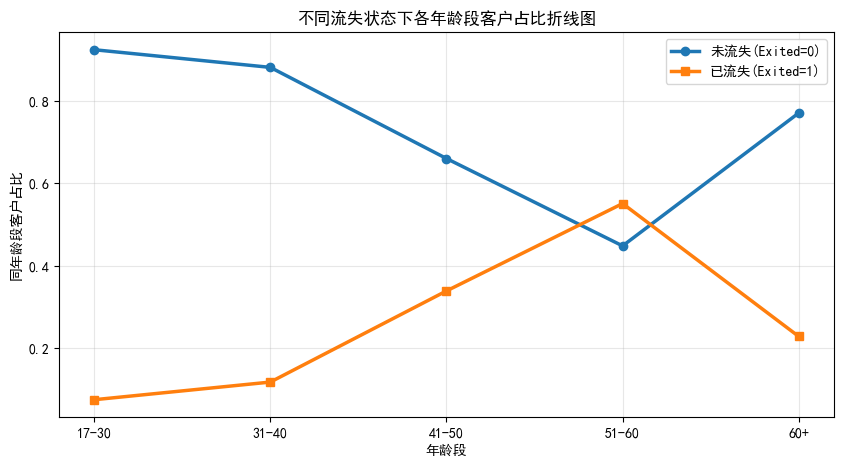

In [12]:
# ====================== 不同流失状态下年龄占比折线图 ======================
# 年龄分层
age_bin = [17,30,40,50,60,100]
age_label = ["17-30","31-40","41-50","51-60","60+"]
df["年龄段"] = pd.cut(df["Age"], bins=age_bin, labels=age_label)
# 分组计算各年龄段内流失/未流失占比
age_pct = pd.crosstab(df["年龄段"], df["Exited"], normalize="index")

plt.figure(figsize=(10,5))
plt.plot(age_pct.index, age_pct[0], marker="o", linewidth=2.5, label="未流失(Exited=0)")
plt.plot(age_pct.index, age_pct[1], marker="s", linewidth=2.5, label="已流失(Exited=1)")
plt.xlabel("年龄段")
plt.ylabel("同年龄段客户占比")
plt.title("不同流失状态下各年龄段客户占比折线图")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(desktop + r"\年龄流失折线图.png", dpi=300, bbox_inches="tight")
plt.show()

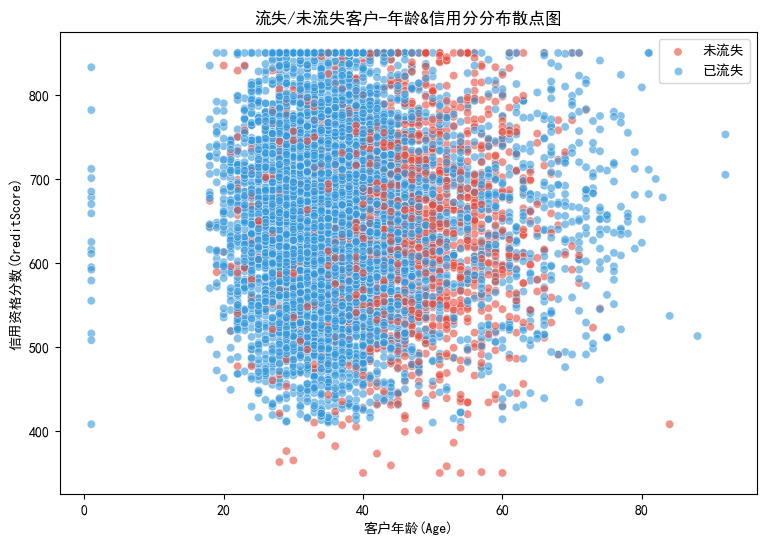

In [13]:
# ====================== 年龄-信用分 流失分组散点图 ======================
plt.figure(figsize=(9,6))
# 0未流失，1已流失
sns.scatterplot(data=df, x="Age", y="CreditScore", hue="Exited", palette=["#3498db","#e74c3c"], alpha=0.6)
plt.xlabel("客户年龄(Age)")
plt.ylabel("信用资格分数(CreditScore)")
plt.title("流失/未流失客户-年龄&信用分分布散点图")
plt.legend(["未流失","已流失"])
plt.savefig(desktop + r"\信用年龄散点图.png", dpi=300, bbox_inches="tight")
plt.show()

===== 表4 户龄-流失透视表（组内占比） =====
Tenure     0      1      2      3      4      5    6      7      8      9   \
Exited                                                                       
0       0.779  0.778  0.812  0.796  0.796  0.791  0.8  0.841  0.811  0.783   
1       0.221  0.222  0.188  0.204  0.204  0.209  0.2  0.159  0.189  0.217   

Tenure     10  
Exited         
0       0.802  
1       0.198  


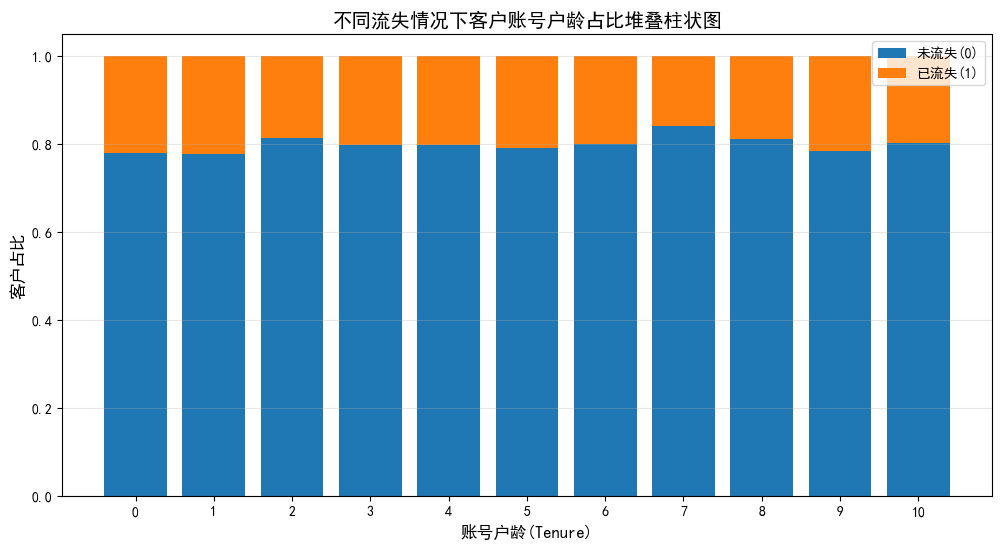

In [15]:
# ====================== Tenure户龄透视表+堆叠柱状图 ======================
pivot_table = pd.crosstab(
    index=df["Exited"], 
    columns=df["Tenure"], 
    normalize="columns"  
)

print("===== 表4 户龄-流失透视表（组内占比） =====")
print(pivot_table.round(3))

# 绘制堆叠柱状图
plt.figure(figsize=(12, 6))

# pivot_table.loc[0]：未流失客户在每个户龄下的占比
# pivot_table.loc[1]：已流失客户在每个户龄下的占比
plt.bar(pivot_table.columns, pivot_table.loc[0], label="未流失(0)", color="#1f77b4")
plt.bar(pivot_table.columns, pivot_table.loc[1], bottom=pivot_table.loc[0], label="已流失(1)", color="#ff7f0e")

# 美化设置
plt.xlabel("账号户龄(Tenure)", fontsize=12)
plt.ylabel("客户占比", fontsize=12)
plt.title("不同流失情况下客户账号户龄占比堆叠柱状图", fontsize=14)
plt.legend(loc="upper right")
plt.xticks(range(0, 11))  # 户龄0~10全部显示
plt.ylim(0, 1.05)         # y轴设到1，因为是占比，每根柱子高度为1
plt.grid(axis='y', alpha=0.3)

# 保存图片
plt.savefig(desktop + r"\户龄流失占比堆叠柱状图.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
# ====================== 新老客户&资产分层 + 输出result3.xlsx + 流失热力图 ======================
## (1) 户龄分层→Status，资产分层→AssetStage，保存result3.xlsx
def get_status(ten):
    if ten <=3:
        return "新客户"
    elif ten <=6:
        return "稳定客户"
    else:
        return "老客户"

def get_asset(bal):
    if bal <=50000:
        return "低资产"
    elif bal <=90000:
        return "中下资产"
    elif bal <=120000:
        return "中上资产"
    else:
        return "高资产"

# 生成新字段
df["Status"] = df["Tenure"].apply(get_status)
df["AssetStage"] = df["Balance"].apply(get_asset)
# 保存文件
df.to_excel(r"C:\Users\Administrator\Desktop\result3.xlsx", index=False)
print("✅ 分层数据已保存：桌面result3.xlsx")

✅ 分层数据已保存：桌面result3.xlsx


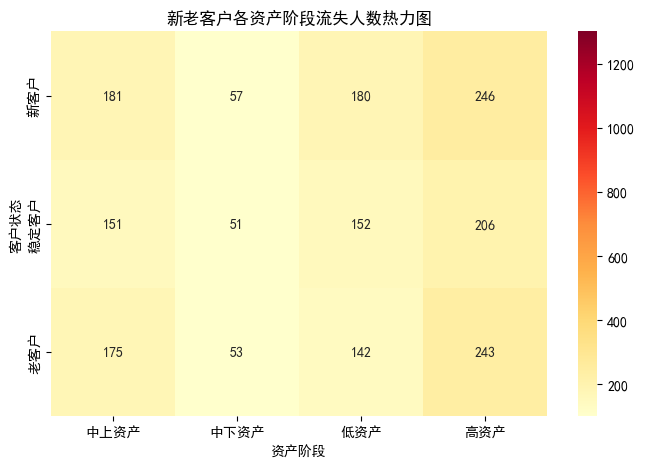

In [17]:
## (2) 统计各(Status,AssetStage)流失数量+热力图
heat_df = pd.crosstab(index=df["Status"], columns=df["AssetStage"], values=df["Exited"], aggfunc="sum")
plt.figure(figsize=(8,5))
sns.heatmap(heat_df, annot=True, cmap="YlOrRd", vmin=100, vmax=1300, fmt="d")
plt.title("新老客户各资产阶段流失人数热力图")
plt.xlabel("资产阶段")
plt.ylabel("客户状态")
plt.savefig(desktop + r"\资产流失热力图.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
# 读取任务3生成的分层数据
df = pd.read_excel(r"C:\Users\Administrator\Desktop\result3.xlsx")

In [19]:
# =========(1) 构建IsActiveStatus：户龄分层(新/稳定/老)+IsActiveMember(0/1) 查表7赋值========
def get_active_status(row):
    status = row["Status"]    # 新客户/稳定客户/老客户
    active_flag = row["IsActiveMember"] # 0不活跃，1活跃
    # 表7规则：
    # 新客户：0→0，1→3
    # 稳定客户：0→1，1→4
    # 老客户：0→2，1→5
    if status == "新客户":
        return 0 if active_flag == 0 else 3
    elif status == "稳定客户":
        return 1 if active_flag == 0 else 4
    elif status == "老客户":
        return 2 if active_flag == 0 else 5
df["IsActiveStatus"] = df.apply(get_active_status, axis=1)

# =========(2) 构建IsActiveAssetStage：资产分层+IsActiveMember 查表8赋值========
def get_active_asset(row):
    asset = row["AssetStage"]
    active_flag = row["IsActiveMember"]
    # 表8：低0/6；中下1/7；中上2/8；高3/9
    map_dict = {
        "低资产": [0,6],
        "中下资产": [1,7],
        "中上资产": [2,8],
        "高资产": [3,9]
    }
    return map_dict[asset][active_flag]
df["IsActiveAssetStage"] = df.apply(get_active_asset, axis=1)

# =========(3) 构建CrCardAssetStage：资产分层+HasCrCard(0/1) 查表9赋值========
def get_crcard_asset(row):
    asset = row["AssetStage"]
    cr_flag = row["HasCrCard"] #0无信用卡，1有信用卡
    # 表9规则
    rule = {
        "低资产":[0,6],
        "中下资产":[2,7],
        "中上资产":[5,9],
        "高资产":[5,9]
    }
    return rule[asset][cr_flag]
df["CrCardAssetStage"] = df.apply(get_crcard_asset, axis=1)

In [20]:
# 保存最终结果文件result4.xlsx
df.to_excel(r"C:\Users\Administrator\Desktop\result4.xlsx", index=False)
print("✅ 特征构建完成，文件已保存至桌面：result4.xlsx")
print("新增字段：IsActiveStatus、IsActiveAssetStage、CrCardAssetStage")

✅ 特征构建完成，文件已保存至桌面：result4.xlsx
新增字段：IsActiveStatus、IsActiveAssetStage、CrCardAssetStage


In [21]:
train_path = r"C:\Users\Administrator\Desktop\result4.xlsx"
test_path = r"C:\Users\Administrator\Desktop\long-customer-test.csv"
df_train = pd.read_excel(train_path)
df_test = pd.read_csv(test_path)

In [22]:
# ================== 特征分组定义 ==================
base_9 = ["CreditScore","Gender","Age","Tenure","Balance","NumOfProducts","HasCrCard","IsActiveMember","EstimatedSalary"]
derive_3 = ["IsActiveStatus","IsActiveAssetStage","CrCardAssetStage"]
all_12 = base_9 + derive_3

# 训练集标签
y = df_train["Exited"]
# 固定随机拆分，保证三组训练/验证样本完全一致（控制变量）
X_raw = df_train[all_12]
scaler_all = StandardScaler()
X_scaled_all = scaler_all.fit_transform(X_raw)
X_tr_all,X_val_all,y_tr,y_val = train_test_split(X_scaled_all,y,test_size=0.2,random_state=42,stratify=y)

# 拆分三组特征的训练/验证数据
# A组：9原生
idx_9 = [all_12.index(i) for i in base_9]
X_tr_9 = X_tr_all[:,idx_9]
X_val_9 = X_val_all[:,idx_9]
# B组：3派生
idx_3 = [all_12.index(i) for i in derive_3]
X_tr_3 = X_tr_all[:,idx_3]
X_val_3 = X_val_all[:,idx_3]
# C组：12全量
X_tr_12 = X_tr_all
X_val_12 = X_val_all

In [23]:
# 统一建模函数（固定模型超参，只换特征）
def train_evaluate(Xtrain,Xval,ytrain,yval,exp_name):
    rf = RandomForestClassifier(n_estimators=150,class_weight="balanced",random_state=42)
    rf.fit(Xtrain,ytrain)
    y_pred = rf.predict(Xval)

    cm = confusion_matrix(yval, y_pred)
    TN, FP, FN, TP = cm.ravel()
    print(f"\n{exp_name} 混淆矩阵：\n{cm}")
    print(f"TN={TN}, FP={FP}, FN={FN}, TP={TP}")
    
    y_prob = rf.predict_proba(Xval)[:,1]
    acc = accuracy_score(yval,y_pred)
    prec = precision_score(yval,y_pred)
    rec = recall_score(yval,y_pred)
    f1 = f1_score(yval,y_pred)
    auc = roc_auc_score(yval,y_prob)
    print(f"\n========== {exp_name} 模型精度 ==========")
    print(f"准确率Acc:{acc:.4f} | 精确率Prec:{prec:.4f}")
    print(f"召回率Rec:{rec:.4f} | F1分数:{f1:.4f} | AUC:{auc:.4f}")
    return {"acc":acc,"prec":prec,"rec":rec,"f1":f1,"auc":auc},rf

In [24]:
# 分别训练三组
res_A,model_A = train_evaluate(X_tr_9,X_val_9,y_tr,y_val,"A组【9个原生基础特征】")
res_B,model_B = train_evaluate(X_tr_3,X_val_3,y_tr,y_val,"B组【仅3个派生特征】")
res_C,model_C = train_evaluate(X_tr_12,X_val_12,y_tr,y_val,"C组【9+3=12全特征】")


A组【9个原生基础特征】 混淆矩阵：
[[1430   43]
 [ 241  126]]
TN=1430, FP=43, FN=241, TP=126

========== A组【9个原生基础特征】 模型精度 ==========
准确率Acc:0.8457 | 精确率Prec:0.7456
召回率Rec:0.3433 | F1分数:0.4701 | AUC:0.8369

B组【仅3个派生特征】 混淆矩阵：
[[900 573]
 [167 200]]
TN=900, FP=573, FN=167, TP=200

========== B组【仅3个派生特征】 模型精度 ==========
准确率Acc:0.5978 | 精确率Prec:0.2587
召回率Rec:0.5450 | F1分数:0.3509 | AUC:0.6189

C组【9+3=12全特征】 混淆矩阵：
[[1429   44]
 [ 234  133]]
TN=1429, FP=44, FN=234, TP=133

========== C组【9+3=12全特征】 模型精度 ==========
准确率Acc:0.8489 | 精确率Prec:0.7514
召回率Rec:0.3624 | F1分数:0.4890 | AUC:0.8341


In [25]:
# ================== 汇总对比表格 ==================
res_df = pd.DataFrame([res_A,res_B,res_C],index=["A:9原生特征","B:3派生特征","C:12组合特征"])
print("\n===== 三组实验指标汇总对比表 =====")
print(res_df.round(4))


===== 三组实验指标汇总对比表 =====
             acc    prec     rec      f1     auc
A:9原生特征   0.8457  0.7456  0.3433  0.4701  0.8369
B:3派生特征   0.5978  0.2587  0.5450  0.3509  0.6189
C:12组合特征  0.8489  0.7514  0.3624  0.4890  0.8341


In [26]:
# ================== 测试集：先构造3派生特征，三套模型分别预测（可选，只保存C组result5.xlsx） ==================
# 测试集生成派生特征（和任务4规则一致）
def get_status(ten):
    if ten <=3:return "新客户"
    elif ten <=6:return "稳定客户"
    else:return "老客户"
def get_asset(bal):
    if bal <=50000:return "低资产"
    elif bal <=90000:return "中下资产"
    elif bal <=120000:return "中上资产"
    else:return "高资产"
df_test["Status"] = df_test["Tenure"].apply(get_status)
df_test["AssetStage"] = df_test["Balance"].apply(get_asset)

def cal_IsActiveStatus(row):
    d = {"新客户":[0,3],"稳定客户":[1,4],"老客户":[2,5]}
    return d[row["Status"]][row["IsActiveMember"]]
def cal_IsActiveAssetStage(row):
    d = {"低资产":[0,6],"中下资产":[1,7],"中上资产":[2,8],"高资产":[3,9]}
    return d[row["AssetStage"]][row["IsActiveMember"]]
def cal_CrCardAssetStage(row):
    d = {"低资产":[0,6],"中下资产":[2,7],"中上资产":[5,9],"高资产":[5,9]}
    return d[row["AssetStage"]][row["HasCrCard"]]

df_test["IsActiveStatus"] = df_test.apply(cal_IsActiveStatus,axis=1)
df_test["IsActiveAssetStage"] = df_test.apply(cal_IsActiveAssetStage,axis=1)
df_test["CrCardAssetStage"] = df_test.apply(cal_CrCardAssetStage,axis=1)

# 测试集特征拆分
Xtest_all = df_test[all_12]
Xtest_scaled = scaler_all.transform(Xtest_all)
Xtest_9 = Xtest_scaled[:,idx_9]
Xtest_3 = Xtest_scaled[:,idx_3]
Xtest_12 = Xtest_scaled

In [27]:
# C组最优模型输出result5.xlsx（题目要求保存该文件）
pred_C = model_C.predict(Xtest_12)
out_df = pd.DataFrame({"CustomerId":df_test["CustomerId"],"Exited_Pred":pred_C})
out_df.to_excel(r"C:\Users\Administrator\Desktop\result5.xlsx",index=False)
print("\n✅ C组全特征模型预测结果已保存至桌面result5.xlsx")
print("前5个客户预测结果：\n",out_df.head())


✅ C组全特征模型预测结果已保存至桌面result5.xlsx
前5个客户预测结果：
    CustomerId  Exited_Pred
0    15647311            0
1    15737452            1
2    15577657            0
3    15589475            1
4    15687946            0
